# ***Seasonal Agriculture Performance Analysis***

Domain: Agriculture

### **Tools:**
**Programming:**
Python
**Data Analysis:**
Pandas,
NumPy
**Visualization:**
Matplotlib,
Seaborn
**Environment:**
Google Colab
**Dataset:**
Microsoft Excel


### Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.

###Project Objectives
Understand the structure and quality of the agricultural dataset.
Clean and prepare the data for analysis.
Explore seasonal patterns in the dataset.
Perform descriptive and statistical analysis.
Investigate relationships among relevant variables.
Compare agricultural performance across seasons and other meaningful groups.
Use appropriate univariate, bivariate and multivariate visualizations.
Identify significant findings from the data.
Develop evidence-based insights and recommendations.

Dataset
The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

Dataset file: seasonal_agriculture_performance_dataset.csv

**Import libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option('display.max_columns', None)

***Load the Excel dataset***

In [6]:
df = pd.read_excel("seasonal_agriculture_performance_dataset.xlsx")

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [7]:
df.shape

(4000, 28)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [9]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


## Feature / Variable Review

The dataset contains different types of variables relevant to seasonal agricultural performance.

### Identifier Variables
- Farm_ID

### Categorical Variables
- State
- District
- Crop
- Season
- Irrigation_Method
- Seed_Quality

### Environmental Variables
- Rainfall
- Temperature
- Humidity
- Sunlight
- Soil pH
- Soil Moisture

### Resource / Operational Variables
- Nitrogen
- Phosphorus
- Potassium
- Fertilizer
- Pesticide
- Irrigation
- Water Used
- Water Efficiency

### Production / Performance Variables
- Yield
- Production
- Disease/Pest Risk

### Economic Variables
- Market Price
- Total Cost
- Revenue
- Profit


***Data Cleaning***

In [10]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [43]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
Farm_ID,0.0
State,0.0
District,0.0
Crop,0.0
Season,0.0
Farm_Area_Hectares,0.0
Rainfall_mm,0.0
Avg_Temperature_C,0.0
Humidity_pct,0.0
Sunlight_Hours_Day,0.0


In [11]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [56]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


***Check Categories***

In [13]:
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [14]:
df['Crop'].value_counts()

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


In [15]:
df['State'].value_counts()

,count
State,
Andhra Pradesh,529
Telangana,516
Maharashtra,512
Madhya Pradesh,497
Karnataka,489
Gujarat,488
Tamil Nadu,485
Punjab,484


In [16]:
df['Irrigation_Method'].value_counts()

,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


***Seasonal Performance Analysis***

In [17]:
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65
Rabi,5.04,41.49,601526.05,513836.58,87689.47
Zaid,4.64,38.89,519171.90,543976.73,-24804.82


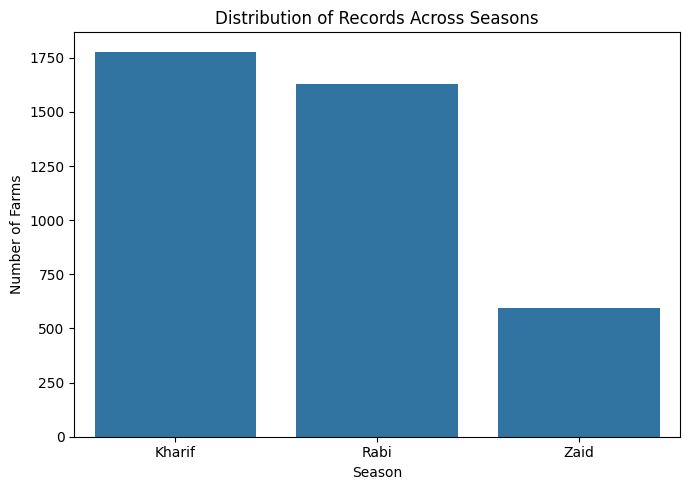

In [57]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Season')

plt.title('Distribution of Records Across Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Farms')

plt.tight_layout()
plt.show()

***Average yield by Season***

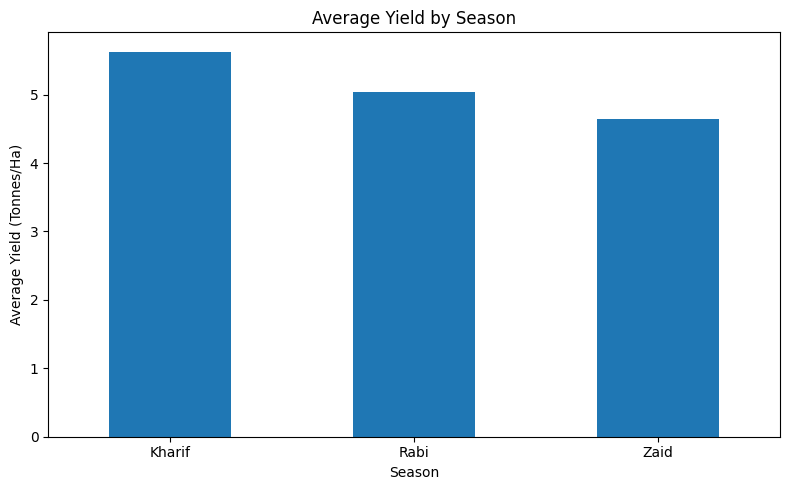

In [18]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
season_yield.plot(kind='bar')
plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

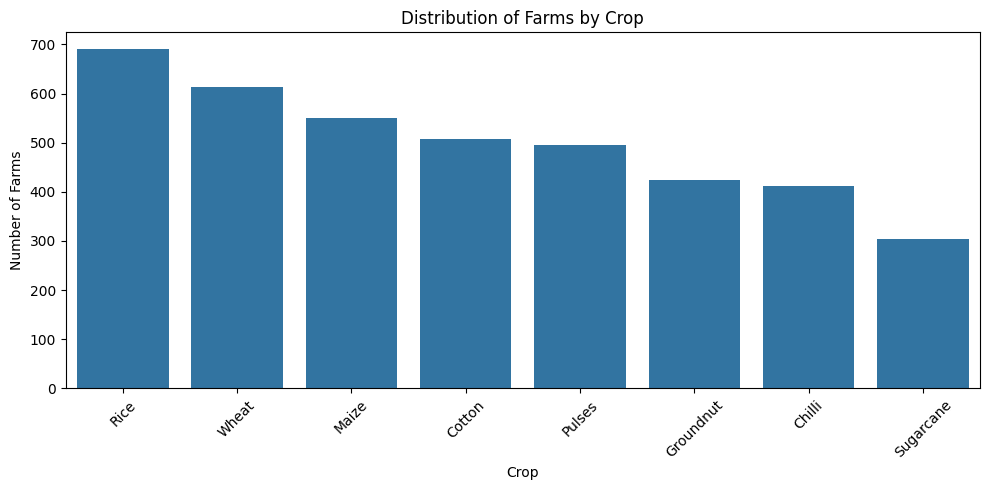

In [58]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Crop',
    order=df['Crop'].value_counts().index
)

plt.title('Distribution of Farms by Crop')
plt.xlabel('Crop')
plt.ylabel('Number of Farms')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

***Profit Analysis***

In [19]:
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

season_profit

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


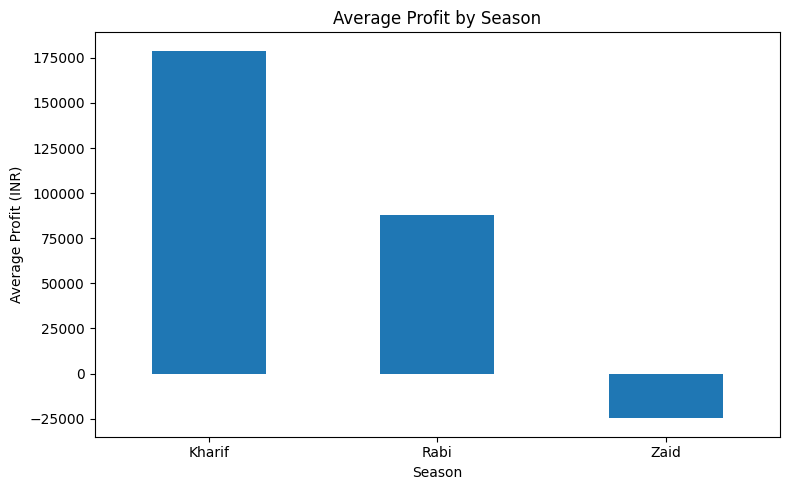

In [20]:
plt.figure(figsize=(8,5))
season_profit.plot(kind='bar')
plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
df['Profit_Margin_pct'] = (
    df['Profit_INR'] / df['Revenue_INR']
) * 100

In [22]:
df.groupby('Season')['Profit_Margin_pct'].mean().round(2)

,Profit_Margin_pct
Season,
Kharif,-38.64
Rabi,-44.27
Zaid,-69.35


***Environment Analysis***

In [23]:
environment_summary = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Sunlight_Hours_Day': 'mean',
    'Soil_Moisture_pct': 'mean'
}).round(2)

environment_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


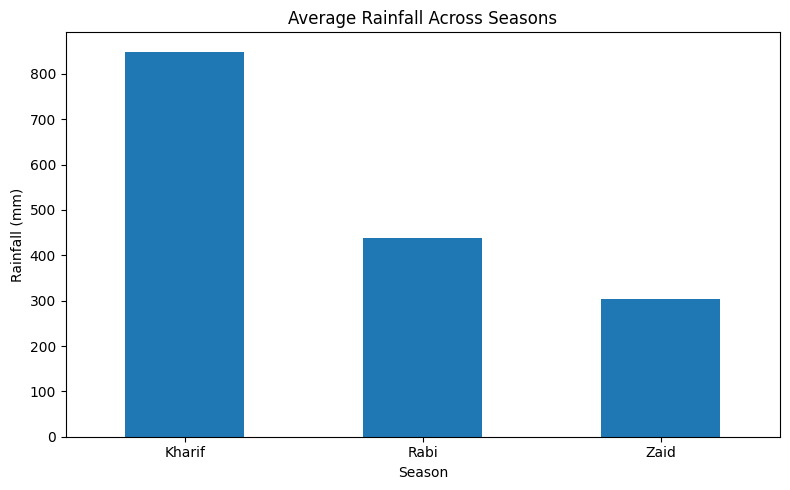

In [24]:
plt.figure(figsize=(8,5))

rainfall = df.groupby('Season')['Rainfall_mm'].mean()

rainfall.plot(kind='bar')

plt.title('Average Rainfall Across Seasons')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

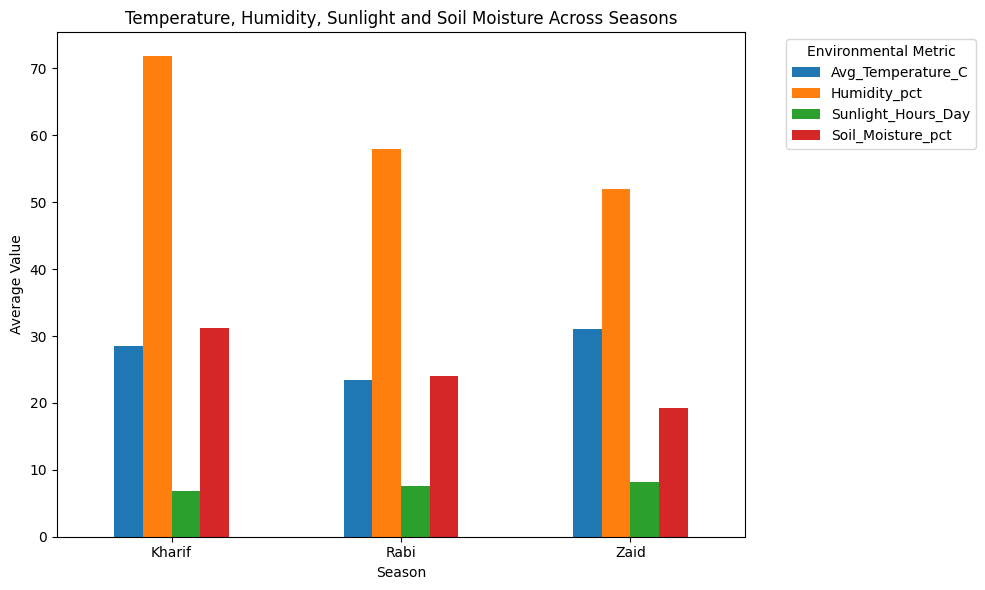

In [25]:
environment_small = df.groupby('Season').agg({
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Sunlight_Hours_Day': 'mean',
    'Soil_Moisture_pct': 'mean'
})

environment_small.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Temperature, Humidity, Sunlight and Soil Moisture Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(
    title='Environmental Metric',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

***Bivariate #1: Rainfall vs Yield***

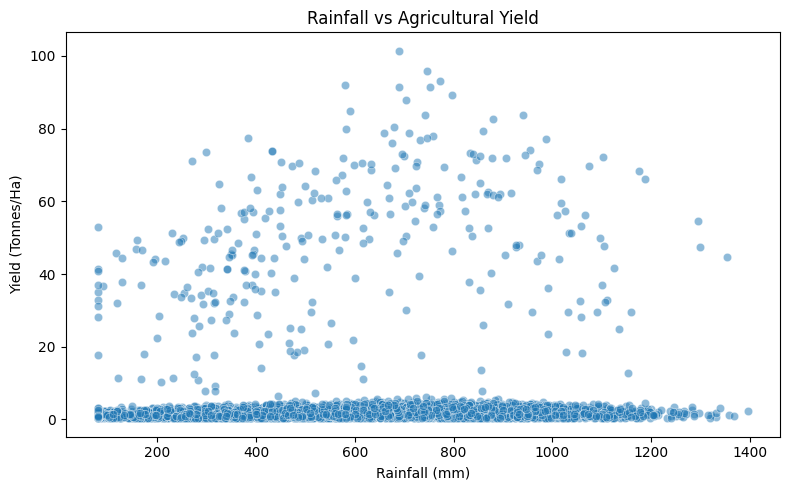

In [59]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    alpha=0.5
)

plt.title('Rainfall vs Agricultural Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

***Crop X Season Analsyis***

In [26]:
crop_season_yield = pd.pivot_table(
    df,
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
).round(2)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


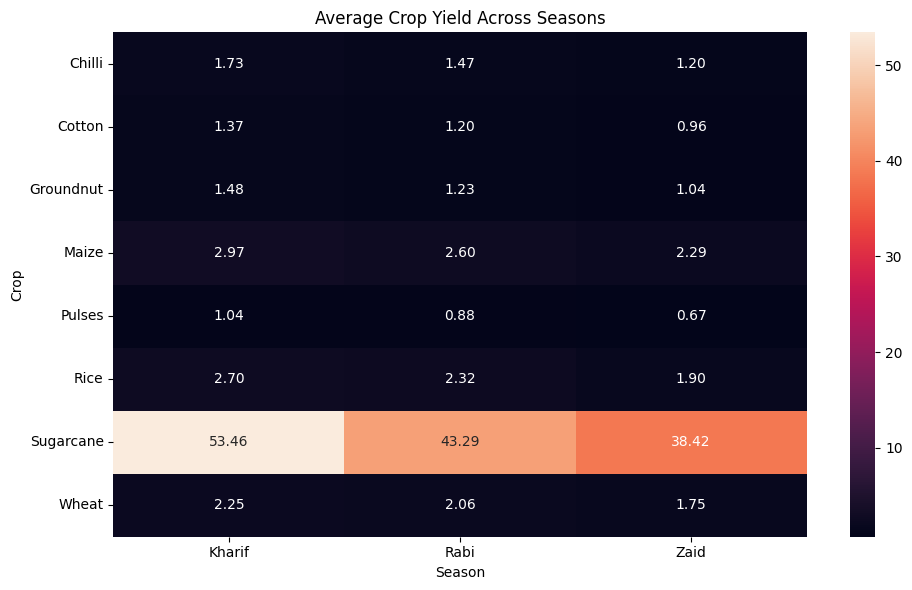

In [27]:
plt.figure(figsize=(10,6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f'
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()


***Resource Usage***

In [28]:
irrigation_season = pd.crosstab(
    df['Season'],
    df['Irrigation_Method'],
    normalize='index'
) * 100

irrigation_season.round(2)

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


In [29]:
water_summary = df.groupby('Season').agg({
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

water_summary

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,6102.20,5.89
Rabi,5846.99,5.19
Zaid,6419.89,4.41


***Bivariate #2: Farm Area vs Production***

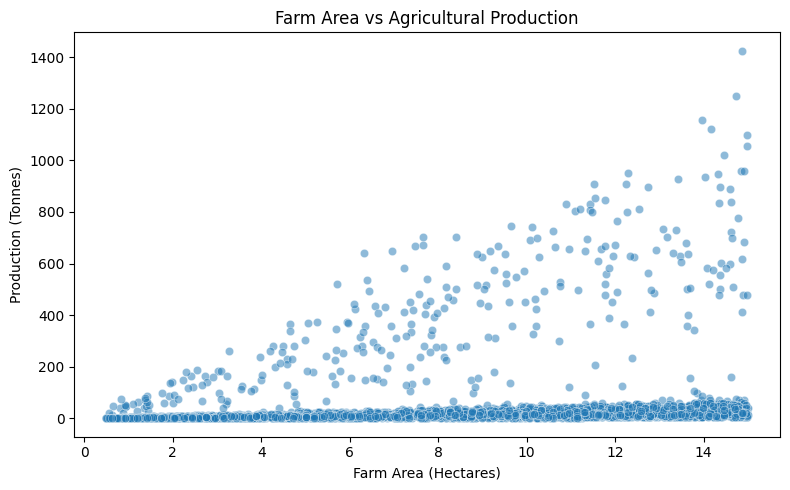

In [60]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Farm_Area_Hectares',
    y='Production_Tonnes',
    alpha=0.5
)

plt.title('Farm Area vs Agricultural Production')
plt.xlabel('Farm Area (Hectares)')
plt.ylabel('Production (Tonnes)')

plt.tight_layout()
plt.show()

***Economic Analysis***

In [30]:
economic_summary = df.groupby('Season').agg({
    'Market_Price_INR_Tonne': 'mean',
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

economic_summary

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,44850.91,531804.41,710719.06,178914.65
Rabi,44747.97,513836.58,601526.05,87689.47
Zaid,44212.03,543976.73,519171.90,-24804.82


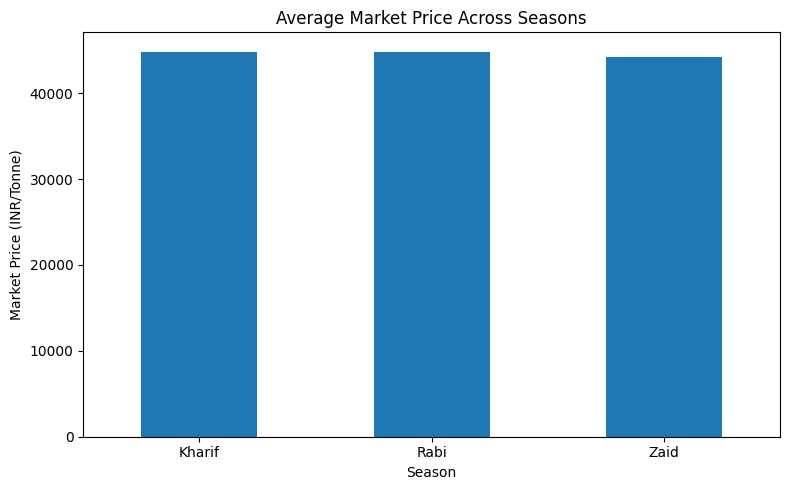

In [31]:
# Average Market Price by Season

market_price = df.groupby('Season')['Market_Price_INR_Tonne'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

market_price.plot(kind='bar')

plt.title('Average Market Price Across Seasons')
plt.xlabel('Season')
plt.ylabel('Market Price (INR/Tonne)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

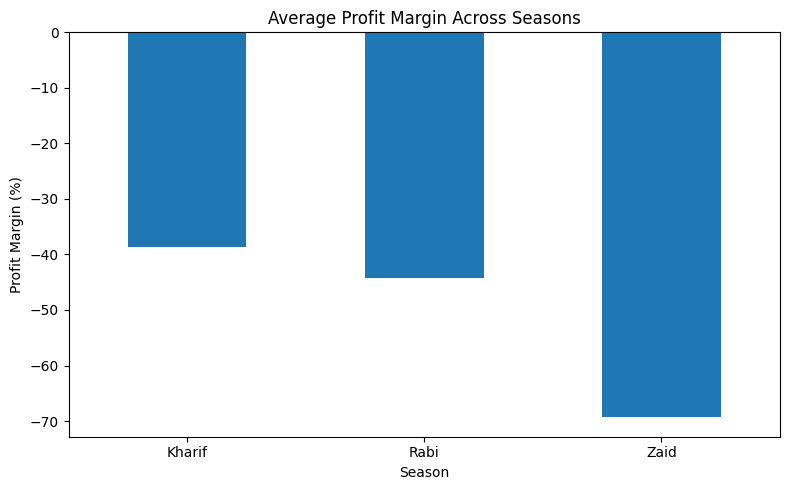

In [32]:
profit_margin = df.groupby('Season')['Profit_Margin_pct'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(8,5))

profit_margin.plot(kind='bar')

plt.title('Average Profit Margin Across Seasons')
plt.xlabel('Season')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [33]:
df['Profit_Margin_pct'] = (
    df['Profit_INR'] / df['Revenue_INR']
) * 100

In [34]:
economic_efficiency = df.groupby('Season').agg({
    'Market_Price_INR_Tonne': 'mean',
    'Profit_Margin_pct': 'mean'
}).round(2)

economic_efficiency

,Market_Price_INR_Tonne,Profit_Margin_pct
Season,,
Kharif,44850.91,-38.64
Rabi,44747.97,-44.27
Zaid,44212.03,-69.35


In [35]:
economic_financials = df.groupby('Season').agg({
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

economic_financials

,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,
Kharif,531804.41,710719.06,178914.65
Rabi,513836.58,601526.05,87689.47
Zaid,543976.73,519171.90,-24804.82


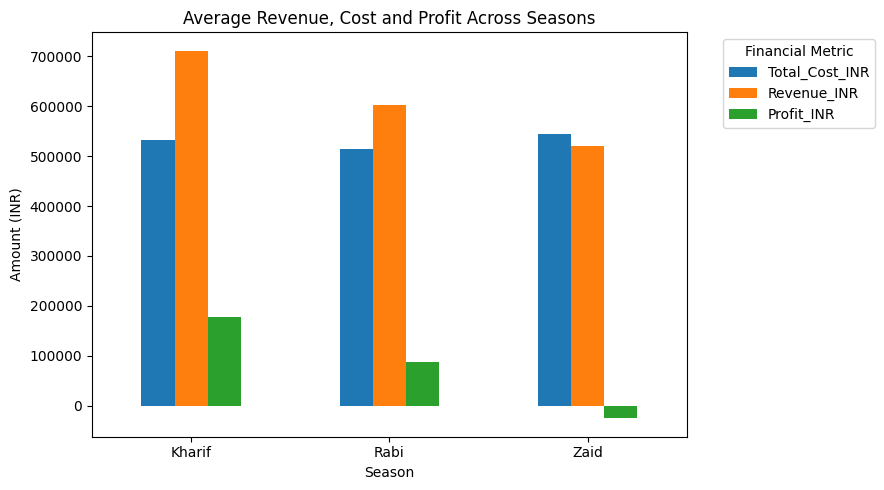

In [36]:
economic_financials.plot(
    kind='bar',
    figsize=(9,5)
)

plt.title('Average Revenue, Cost and Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)

plt.legend(
    title='Financial Metric',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

***Correlation analysis***

In [37]:
corr_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct',
    'Profit_INR'
]

correlation = df[corr_columns].corr()

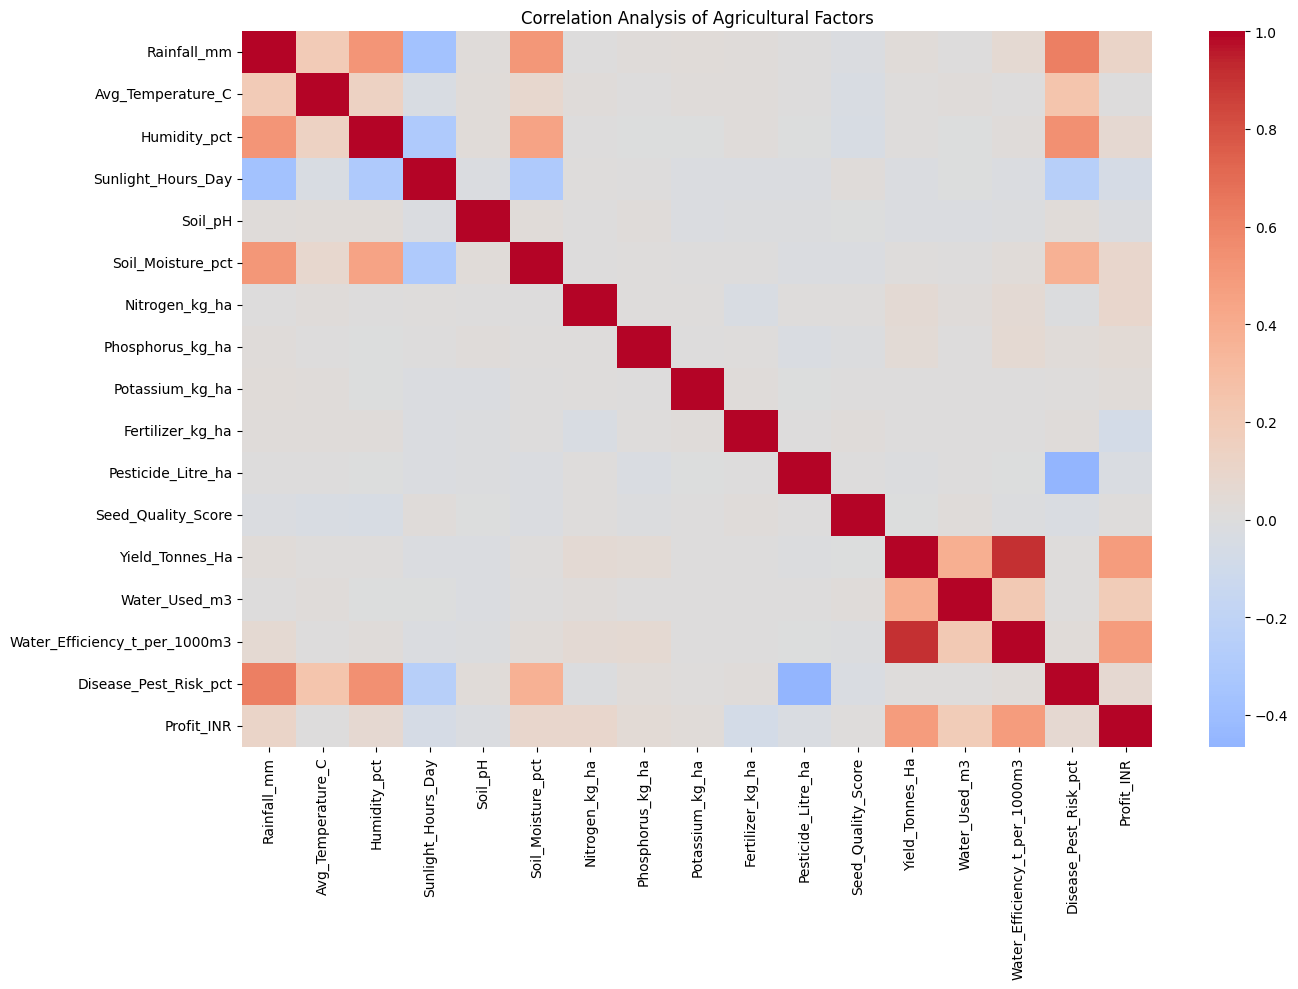

In [38]:
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Analysis of Agricultural Factors')
plt.tight_layout()
plt.show()

*** To Find factors most related to yield***

In [39]:
yield_corr = correlation['Yield_Tonnes_Ha'].sort_values(
    ascending=False
)

yield_corr

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Profit_INR,0.488466
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Disease_Pest_Risk_pct,0.014292
Humidity_pct,0.012297
Soil_Moisture_pct,0.010999


***Outer Analysis***

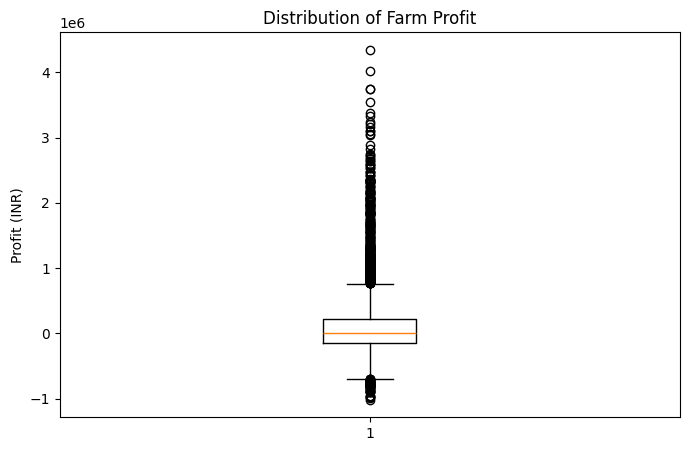

In [40]:
plt.figure(figsize=(8,5))

plt.boxplot(df['Profit_INR'].dropna())

plt.title('Distribution of Farm Profit')
plt.ylabel('Profit (INR)')

plt.show()

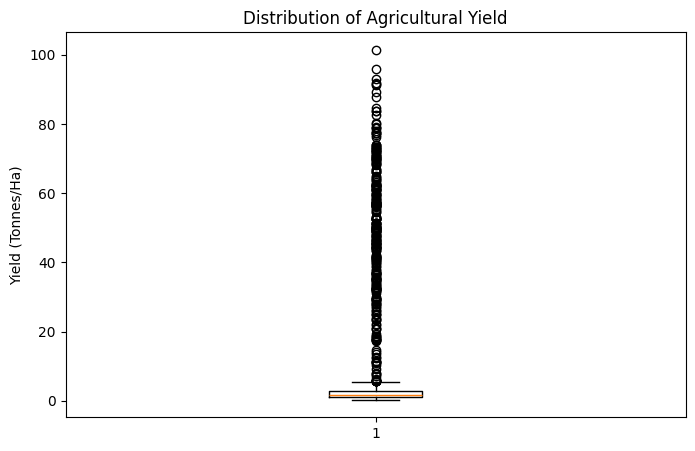

In [41]:
plt.figure(figsize=(8,5))

plt.boxplot(df['Yield_Tonnes_Ha'].dropna())

plt.title('Distribution of Agricultural Yield')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [45]:
def profit_category(profit):
    if profit < 0:
        return 'Loss'
    elif profit < 100000:
        return 'Low Profit'
    elif profit < 500000:
        return 'Moderate Profit'
    else:
        return 'High Profit'

df['Profit_Category'] = df['Profit_INR'].apply(profit_category)

df[['Profit_INR', 'Profit_Category']].head()

,Profit_INR,Profit_Category
0,-11852,Loss
1,-451950,Loss
2,-124744,Loss
3,-95704,Loss
4,-144352,Loss


In [46]:
season_profit_category = pd.crosstab(
    df['Season'],
    df['Profit_Category'],
    normalize='index'
) * 100

season_profit_category.round(2)

Profit_Category,High Profit,Loss,Low Profit,Moderate Profit
Season,,,,
Kharif,15.85,42.21,17.54,24.40
Rabi,11.19,51.14,17.39,20.28
Zaid,9.26,64.48,13.30,12.96


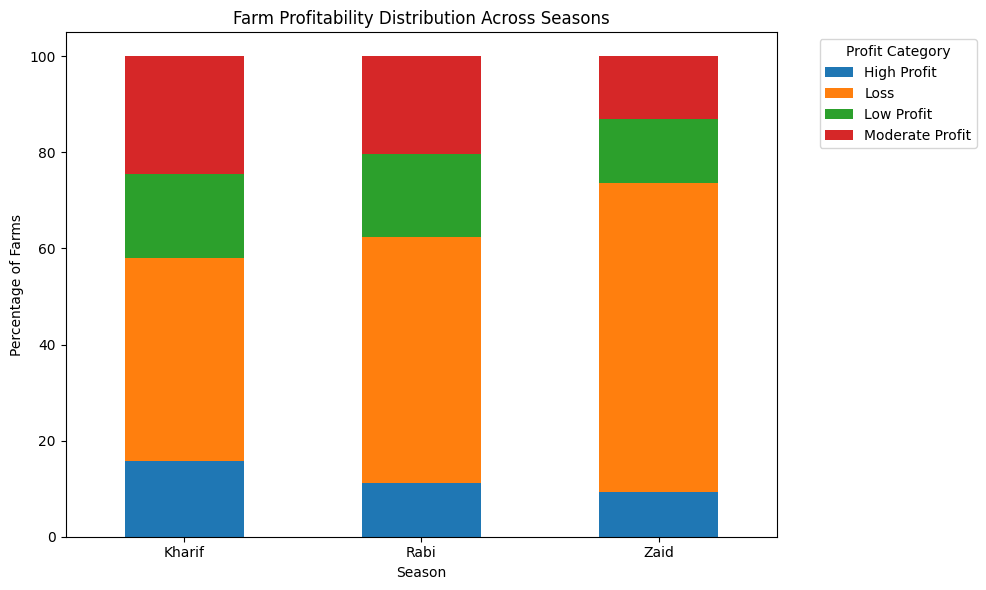

In [47]:
season_profit_category.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Farm Profitability Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Percentage of Farms')
plt.xticks(rotation=0)

plt.legend(
    title='Profit Category',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [48]:
season_profitability = df.groupby('Season').agg({
    'Revenue_INR': 'sum',
    'Profit_INR': 'sum'
})

season_profitability['Profit_Margin_pct'] = (
    season_profitability['Profit_INR'] /
    season_profitability['Revenue_INR']
) * 100

season_profitability.round(2)

,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,
Kharif,1264369200,318289158,25.17
Rabi,978682881,142670768,14.58
Zaid,308388111,-14734066,-4.78


In [49]:
season_profitability = df.groupby('Season').agg({
    'Revenue_INR': 'sum',
    'Profit_INR': 'sum'
})

season_profitability['Profit_Margin_pct'] = (
    season_profitability['Profit_INR'] /
    season_profitability['Revenue_INR']
) * 100

season_profitability.round(2)

,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,
Kharif,1264369200,318289158,25.17
Rabi,978682881,142670768,14.58
Zaid,308388111,-14734066,-4.78


***Regional X Seasonal Analysis***

In [50]:
state_season_yield = pd.pivot_table(
    df,
    values='Yield_Tonnes_Ha',
    index='State',
    columns='Season',
    aggfunc='mean'
).round(2)

state_season_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.45
Gujarat,6.34,5.44,4.07
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.48
Maharashtra,5.43,5.50,2.28
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


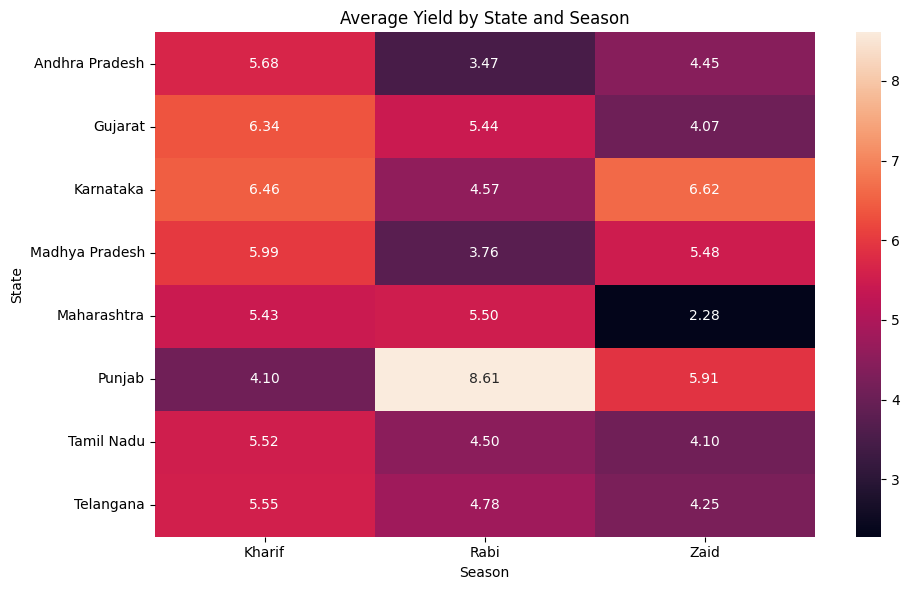

In [51]:
plt.figure(figsize=(10,6))

sns.heatmap(
    state_season_yield,
    annot=True,
    fmt='.2f'
)

plt.title('Average Yield by State and Season')
plt.xlabel('Season')
plt.ylabel('State')

plt.tight_layout()
plt.show()

***Crop X Season Profitability***

In [52]:
crop_season_profit = pd.pivot_table(
    df,
    values='Profit_INR',
    index='Crop',
    columns='Season',
    aggfunc='mean'
).round(0)

crop_season_profit

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.0,638572.0,448659.0
Cotton,217000.0,107344.0,-53925.0
Groundnut,108265.0,10417.0,-68872.0
Maize,-39333.0,-89133.0,-194049.0
Pulses,43339.0,-14309.0,-139228.0
Rice,-64903.0,-98428.0,-227239.0
Sugarcane,1000791.0,731613.0,583636.0
Wheat,-105872.0,-119955.0,-193209.0


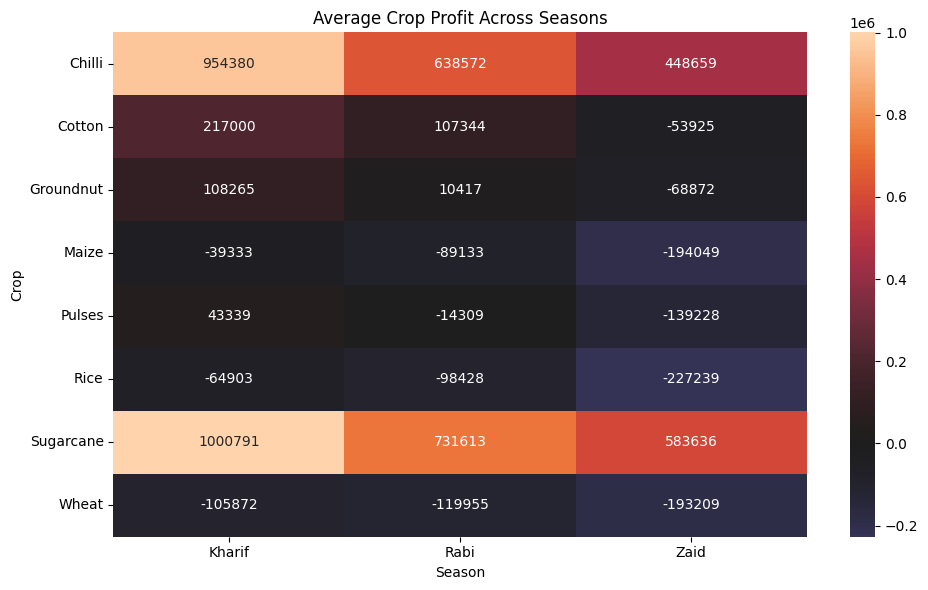

In [53]:
plt.figure(figsize=(10,6))

sns.heatmap(
    crop_season_profit,
    annot=True,
    fmt='.0f',
    center=0
)

plt.title('Average Crop Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

***Statistical Validation***

In [54]:
from scipy.stats import f_oneway

kharif_profit = df[df['Season'] == 'Kharif']['Profit_INR']
rabi_profit = df[df['Season'] == 'Rabi']['Profit_INR']
zaid_profit = df[df['Season'] == 'Zaid']['Profit_INR']

anova_result = f_oneway(
    kharif_profit,
    rabi_profit,
    zaid_profit
)

anova_result

F_onewayResult(statistic=np.float64(34.29175033935195), pvalue=np.float64(1.7124156677360182e-15))

***Best Season–Crop Combination***

In [55]:
best_crop_season = (
    df.groupby(['Crop', 'Season'])['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

best_crop_season.head(10)

,,Profit_INR
Crop,Season,
Sugarcane,Kharif,1.000791e+06
Chilli,Kharif,9.543804e+05
Sugarcane,Rabi,7.316129e+05
Chilli,Rabi,6.385725e+05
Sugarcane,Zaid,5.836358e+05
Chilli,Zaid,4.486591e+05
Cotton,Kharif,2.169995e+05
Groundnut,Kharif,1.082654e+05
Cotton,Rabi,1.073436e+05


# **1. Kharif is strongest overall**

**Average:**

Yield: 5.63 t/ha
Revenue: ₹710,719
Profit: ₹178,915

**versus Zaid:**

Yield: 4.64 t/ha
Revenue: ₹519,172
Profit: −₹24,805

# **2. Seasonal performance varies by region**

Punjab's Rabi yield is around 8.61 t/ha, while Karnataka's Zaid yield reaches around 6.62 t/ha.

This proves that there isn't one universally best season for every region.

# **3. Economic performance is very different**

Using total seasonal profit / total seasonal revenue:

**Kharif**: 25.17%
**Rabi**: 14.58%
**Zaid**: −4.78%

That's a very strong economic insight.

# **4. Zaid shows weaker economic performance**

Observation: Zaid has negative average profit.

Evidence: Average profit ≈ −₹24,805 and overall profit margin ≈ −4.78%.

Interpretation: Zaid farms face weaker economic performance in the available dataset.

Limitation: The analysis does not establish why Zaid is less profitable.

# **5. Crop selection strongly affects seasonal profitability**

Use your actual crop-season profit heatmap.

Observation: Profitability differs substantially across crop-season combinations.

Evidence: Your crop × season profitability analysis shows large differences between combinations.

Interpretation: Crop selection should be evaluated together with season.

Limitation: Other factors such as market conditions and input costs also influence profitability.

# **6. Water efficiency differs across seasons**

Your current result:

Season : Kharif, 	Water Efficiency: 5.89

Season : Rabi,	Water Efficiency: 5.19
Season: Zaid, Water Efficiency:	4.41

Interpretation: Kharif demonstrates the highest average water efficiency among the three seasons.

# **Recommendations**

### 1. Consider region-specific seasonal planning
Since yield performance varies considerably across states and seasons, agricultural planning should consider regional seasonal patterns rather than applying a single seasonal strategy across all regions.

### 2. Evaluate crop selection together with season
The crop-season profitability analysis shows substantial variation between combinations. Crop selection should therefore consider both expected yield and economic performance.

### 3. Improve resource efficiency
Differences in water usage and water efficiency across seasons suggest that resource planning should be adapted to seasonal conditions.

### 4. Prioritize economically viable combinations
Crop-season combinations with consistently stronger profitability can be considered for further investigation before making production decisions.

### 5. Monitor environmental conditions
Rainfall, temperature, humidity, sunlight and soil moisture should be monitored because they show seasonal variation and may be associated with agricultural outcomes.

### 6. Investigate low-profit or loss-making combinations
Zaid and other low-performing crop-season combinations should be investigated further to understand whether environmental, production-cost or market-related factors contribute to weaker profitability.

##**Limitations**

- The analysis is based on the variables available in the provided dataset.
- Observed correlations indicate associations and should not be interpreted as causal relationships.
- Missing numerical values were handled using median imputation, which may reduce some natural variation.
- The dataset represents the available observations and may not capture all real-world agricultural conditions.
- Market prices, environmental conditions and resource usage may be influenced by factors not included in the dataset.
- Statistical significance does not necessarily imply practical or causal significance.
- The findings should therefore be treated as evidence from the dataset rather than universal agricultural conclusions.

# **Conclusion**

The analysis of the seasonal agricultural dataset revealed meaningful differences in agricultural performance across Kharif, Rabi and Zaid seasons. Kharif demonstrated the strongest overall performance in terms of average yield and profitability, while Zaid showed weaker economic outcomes.

The analysis also showed that seasonal performance is not consistent across all regions or crops. State-level and crop-level comparisons revealed substantial variation in yield and profitability across season-specific combinations.

Environmental conditions and resource usage also varied across seasons, while correlation and statistical analysis provided additional evidence of relationships and differences within the dataset.

Overall, the findings demonstrate that agricultural performance should be evaluated using a combination of seasonal, regional, crop, environmental, resource and economic factors rather than relying on a single performance measure.

The results can support further investigation into region-specific crop selection, resource efficiency and seasonal agricultural planning. However, the findings represent associations within the available dataset and should not be interpreted as causal or universally applicable conclusions.**bold text**

### Project Checklist

- [x] Dataset loaded successfully
- [x] Top 5 rows analyzed
- [x] Dataset shape and structure examined
- [x] Data types examined
- [x] Missing values identified and handled
- [x] Duplicate records identified and handled
- [x] Descriptive/statistical analysis performed
- [x] Outliers investigated
- [x] Univariate analysis completed
- [x] Bivariate analysis completed
- [x] Multivariate analysis completed
- [x] Correlation analysis completed
- [x] Seasonal comparisons performed
- [x] At least 3 student-designed analyses completed
- [x] At least 6 meaningful insights documented
- [x] Evidence-based recommendations provided
- [x] Limitations discussed
- [x] Final conclusion provided